In [36]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

In [37]:
# Black-Scholes call option pricing function
def black_scholes_call(S, K, r, sigma, q, T):
    if sigma == 0:
        black_scholes_price = max(0, np.exp(-q*T)*S - np.exp(-r*T)*K)
    else:
        d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        N1 = norm.cdf(d1)
        N2 = norm.cdf(d2)
        black_scholes_price = np.exp(-q*T)*S*N1 - np.exp(-r*T)*K*N2

    return black_scholes_price

In [38]:
# Function to calculate implied volitility using a grid search
def implied_volatility_grid(S, K, r, q, T, S_mkt):
    volatilities = np.linspace(0.01, 2, 500) # Sets range of volatilities to search from
    min_diff = float(99999999999999)
    implied_vol = 0.01

    # Loop through range of volitilites to find one closest to the S_mkt implication
    for sigma in volatilities:
        price = black_scholes_call(S, K, r, sigma, q, T)
        diff = abs(price - S_mkt)
        if diff < min_diff:
            min_diff = diff
            implied_vol = sigma 

    return implied_vol 

In [ ]:
# Download option price data from yahoo finance
ticker = yf.Ticker('SPY')

options = ticker.option_chain(date='2024-10-25') # 30 days from date of running this program (change this to desired range)
calls = options.calls
calls = calls[['strike', 'bid', 'ask']]

In [40]:
# Set parameters
# sp500 = ticker.history(period='1d')['Close'][0] # Use this to find the current price
sp500 = 570.530029296875 # This is value of above code on 2024-09-24
# div_yield = ticker.info['yield'] if ticker.info['yield'] else 0  # Use this to find the current dividend yield
div_yield = 0.0121

# Market parameters
r = 0.04  # Risk-free interest rate assumption 2024-09-24
T = 30 / 365  # Time to expiration (30 days)

In [41]:
calls['S_mkt'] = calls['ask']

# Calculate implied volatilities using grid search
calls['implied_volatility'] = calls.apply(lambda x: implied_volatility_grid(sp500, x['strike'], T, r, div_yield, x['S_mkt']), axis=1)


C:\Users\kale\AppData\Local\Temp\ipykernel_28872\4153499373.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  calls['S_mkt'] = calls['ask']
C:\Users\kale\AppData\Local\Temp\ipykernel_28872\4153499373.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  calls['implied_volatility'] = calls.apply(lambda x: implied_volatility_grid(sp500, x['strike'], T, r, div_yield, x['S_mkt']), axis=1)


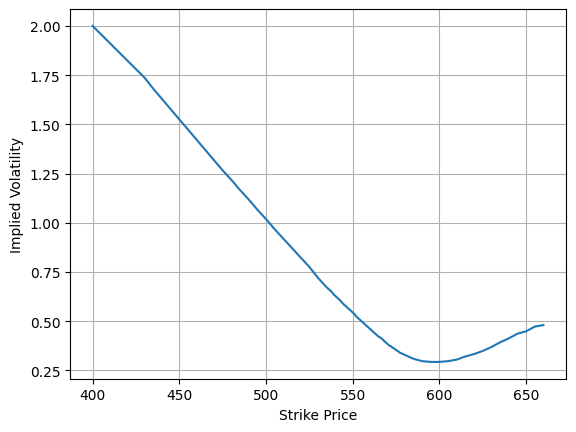

In [42]:
plt.plot(calls['strike'], calls['implied_volatility'], label='Implied Volatility')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.grid(True)
plt.show()

In [43]:
calls['S_mkt_bid'] = calls['bid']

# Calculate implied volatilities using grid search
calls['implied_volatility_bid'] = calls.apply(lambda x: implied_volatility_grid(sp500, x['strike'], T, r, div_yield, x['S_mkt_bid']), axis=1)

C:\Users\kale\AppData\Local\Temp\ipykernel_28872\793979508.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  calls['S_mkt_bid'] = calls['bid']
C:\Users\kale\AppData\Local\Temp\ipykernel_28872\793979508.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  calls['implied_volatility_bid'] = calls.apply(lambda x: implied_volatility_grid(sp500, x['strike'], T, r, div_yield, x['S_mkt_bid']), axis=1)


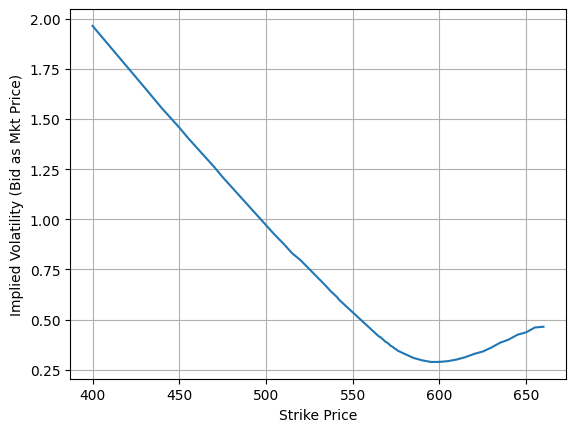

In [44]:
plt.plot(calls['strike'], calls['implied_volatility_bid'], label='Implied Volatility')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility (Bid as Mkt Price)')
plt.grid(True)
plt.show()

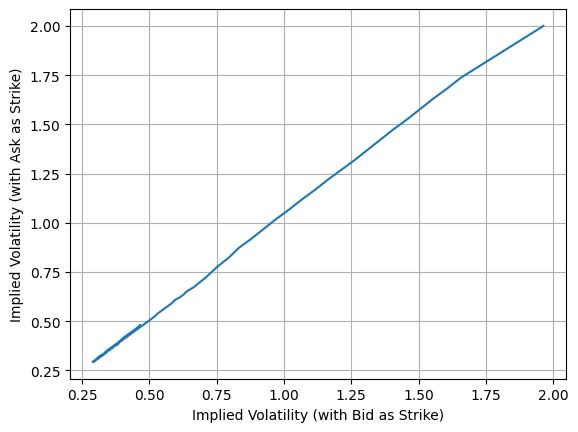

In [45]:
plt.plot(calls['implied_volatility_bid'], calls['implied_volatility'])
plt.ylabel('Implied Volatility (with Ask as Strike)')
plt.xlabel('Implied Volatility (with Bid as Strike)')
plt.grid(True)
plt.show()

In [46]:
# Black-Scholes delta function for a European call option
def call_option_delta(S, K, r, sigma, q, T):
    """
    S = initial stock price
    K = strike price
    r = risk-free rate
    sigma = volitility
    q = dividend yield
    T = time to expiry (in years)
    """
    # N(d1) is the factor by which the discounted expected value of contingent receipt of the stock exceeds the current value of the stock.
    # In simple terms if the option is in the money, d1 tells how far into the money it is
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    delta = norm.cdf(d1)

    return delta

# Black-Scholes gamma function for a European call option
def call_option_gamma(S, K, r, sigma, q, T):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    nd1 = np.exp(-d1 * d1 / 2) / np.sqrt(2 * np.pi)
    gamma = np.exp(-q*T) * nd1 / (S * sigma * np.sqrt(T))
    
    return gamma

In [47]:
# Simulated Delta-Gamme Hedge Profit for writing a call option
def simulated_delta_gamma_hedge_profit(S0, KWritten, KHedge, r, sigma, q, T, mu, M, N, pct):
    """
    S0 = initial stock price
    KWritten = strike price of the option that is written
    KHedge = strike price of the option that is used to hedge
    r = risk-free rate
    sigma = volatility
    q = dividend yield
    T = time to maturity
    mu = expected rate of return
    M = number of simulations
    N = number of time periods
    pct = percentile to be returned
    """
    
    dt = T / N  # Time step
    sigsqrdt = sigma * np.sqrt(dt)  # Volatility term
    drift = (mu - q - 0.5 * sigma**2) * dt  # Drift term
    compound = np.exp(r * dt)  # Compounding factor
    div = np.exp(q * dt) - 1  # Dividend yield factor
    logS0 = np.log(S0)  # Initial log price

    # Initial option prices, and greeks
    priceWritten = black_scholes_call(S0, KWritten, r, sigma, q, T)
    deltaWritten = call_option_delta(S0, KWritten, r, sigma, q, T)
    gammaWritten = call_option_gamma(S0, KWritten, r, sigma, q, T)

    priceHedge = black_scholes_call(S0, KHedge, r, sigma, q, T)
    deltaHedge = call_option_delta(S0, KHedge, r, sigma, q, T)

    # Initial positions: holding 0 stock, writing one call option (so we sell the written option)
    a = deltaWritten - deltaHedge # Delta-neutral position
    b = -gammaWritten / call_option_gamma(S0, KHedge, r, sigma, q, T)  # Gamma-neutral position
    cash = priceWritten - a * S0 - b * priceHedge # Initial cash from writing the option


    # Array to store profits for each simulation
    profit = np.zeros(M)

    # Simulations
    for i in range(M):
        logS = logS0
        cash_sim = cash
        S = S0
        a_sim = a
        b_sim = b

        for j in range(N):
            # Simulate new log stock price using drift and random walk
            logS += drift + sigsqrdt * np.random.randn()
            NewS = np.exp(logS)  # Convert back to stock price

            # Update option prices, delta, gamma
            newPriceWritten = black_scholes_call(NewS, KWritten, r, sigma, q, T)
            newDeltaWritten = call_option_delta(NewS, KWritten, r, sigma, q, T)
            newGammaWritten = call_option_gamma(NewS, KWritten, r, sigma, q, T)

            newPriceHedge = black_scholes_call(NewS, KHedge, r, sigma, q, T)
            newDeltaHedge = call_option_delta(NewS, KHedge, r, sigma, q, T)
            newGammaHedge = call_option_gamma(NewS, KHedge, r, sigma, q, T)

            # Update positions 
            new_a = newDeltaWritten - newDeltaHedge
            new_b = -newGammaWritten / newGammaHedge

            # Update cash position
            cash_sim = cash_sim * compound + a_sim * S * div - (new_a - a_sim) * NewS - (new_b - b_sim) * newPriceHedge

            # Update stock price and hedge positions
            S = NewS
            a_sim = new_a
            b_sim = new_b

        # Calculate final portfolio value 
        final_call_written = max(0, S-KWritten) # Payoff of written call option
        final_call_hedge = max(0, S-KHedge) # Payoff of hedge call option

        final_hedge_value = compound * cash_sim + a_sim * S + b_sim * final_call_hedge
        profit[i] = final_hedge_value - final_call_written  # Profit from delta-gamma hedge

    # Return the desired percentile of profit distribution
    return np.percentile(profit, pct)

        

In [49]:
# Set parameters
S0 = 100
KWritten = 105
KHedge = 110
r = 0.05
sigma = 0.2
q = 0.02
T = 1
mu = 0.1
M = 1000
N = 50
lower_pct = 5
upper_pct = 95

profit_percentile_lower = simulated_delta_gamma_hedge_profit(S0, KWritten, KHedge, r, sigma, q, T, mu, M, N, lower_pct)
profit_percentile_higher = simulated_delta_gamma_hedge_profit(S0, KWritten, KHedge, r, sigma, q, T, mu, M, N, upper_pct)

In [50]:
print(profit_percentile_lower)
print(profit_percentile_higher)

-56.52947912614736
11.834316942051219
